# Two-terminal QH conductance with Kwant — cropped inner transport region

This notebook is identical in workflow to `qh_kwant_transport_two_terminal_JOBLIB.ipynb`, with one geometry optimization: the full Hartree potential is first reshaped under the source/drain mouths exactly as in the original v4 workflow, and **only afterwards** the reshaped outer regions are discarded.

For the left/right current-lead depth `source_drain_depth_nm`, the transport system retains only

```text
xmin + source_drain_depth_nm < x < xmax - source_drain_depth_nm
```

(equivalently, for a symmetric grid `-d + source_drain_depth_nm < x < d - source_drain_depth_nm`).

The source and drain are then attached to the new left/right boundaries of this reduced system. All other physics parameters, energy selection, magnetic-field treatment, JOBLIB sweep logic, observables, and saved output keys are unchanged.

Lead ordering used throughout:

```text
0 = source, left full-width lead
1 = drain, right full-width lead
```


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
import multiprocessing

from module_kwant import *

## 1. Load the Hartree sweep

Set `SWEEP_DIR` to the directory containing subfolders with `metadata.json` and `data.npz`.
The potential key is usually `"U"`.

In [2]:
SWEEP_DIR = Path("data_sweep")
POTENTIAL_KEY = "U"

seq = load_effective_potential_sequence(
    SWEEP_DIR,
    potential_key=POTENTIAL_KEY,
    ground_each_frame=False,
)

print(seq.U_stack_meV.shape, "(nB, ny, nx)")
print("B range:", seq.B_values_T[0], "->", seq.B_values_T[-1], "T")
print("x range:", seq.x_nm.min(), "->", seq.x_nm.max(), "nm")
print("y range:", seq.y_nm.min(), "->", seq.y_nm.max(), "nm")
print("grid spacing a =", seq.a_nm, "nm")

(101, 301, 301) (nB, ny, nx)
B range: 0.8 -> 2.0 T
x range: -1500.0 -> 1500.0 nm
y range: -1500.0 -> 1500.0 nm
grid spacing a = 10.0 nm


## 2. Define a two-terminal Hall bar

The source/drain potential reshaping is performed on the **full** Hartree grid first. A thin wrapper around the v4 preparation routine then removes the two reshaped outer sections before the Kwant builder is called. This keeps the original v4 logic intact while substantially reducing the number of lattice sites.


In [3]:
# Choose one representative frame for visualization/building.
FRAME_INDEX = 50  #min(101, len(seq.B_values_T) - 1)

# Lead-mouth parameters.
source_drain_depth_nm = 750.0     # reshaping depth for left/right current leads

lead_potential_meV = 0.0
smooth_nm = 1e1

lead_specs_2 = (
    LeadSpec(
        "source", "left",
        depth_nm=source_drain_depth_nm,
        lead_potential_meV=lead_potential_meV,
        smooth_nm=smooth_nm,
        smooth_profile="constant_inner",
    ),
    LeadSpec(
        "drain", "right",
        depth_nm=source_drain_depth_nm,
        lead_potential_meV=lead_potential_meV,
        smooth_nm=smooth_nm,
        smooth_profile="constant_inner",
    ),
)

cfg2 = DeviceConfig(
    m_eff=0.067,
    g_factor=-0.0,
    norbs=1,
    disorder=DisorderConfig(amplitude_meV=1e-6, correlation_nm=10.0, seed=12345),
    lead_specs=lead_specs_2,
    reshape_under_leads=True,
    lead_B_mode="zero",
)


# -------------------------------------------------------------------------
# Geometry optimization:
# 1) run the ORIGINAL v4 prepare_frame on the full Hartree grid, so the
#    source/drain mouths are reshaped exactly as before;
# 2) only afterwards discard the reshaped left/right sections;
# 3) make run_one_frame use this same cropped preparation also inside
#    JOBLIB worker processes.
# -------------------------------------------------------------------------

_prepare_frame_full = prepare_frame
_run_one_frame_full = run_one_frame


def crop_prepared_frame_x(prep, crop_depth_nm):
    """
    Return a copy of a v4 PreparedFrame restricted to the inner x interval

        xmin + crop_depth_nm < x < xmax - crop_depth_nm.

    The crop is applied to x_nm and to every prepared ndarray whose final
    spatial dimensions are (ny, nx), plus any 1D x-dependent array.

    This function deliberately acts AFTER the original v4 prepare_frame,
    hence U_for_transport_meV has already undergone the original lead-mouth
    reshaping before the outer regions are thrown away.
    """
    import copy
    import dataclasses

    x = np.asarray(prep.x_nm)
    y = np.asarray(prep.y_nm)
    nx = len(x)
    ny = len(y)

    xmin = float(x.min())
    xmax = float(x.max())

    x_left = xmin + float(crop_depth_nm)
    x_right = xmax - float(crop_depth_nm)

    keep_x = (x > x_left) & (x < x_right)

    if np.count_nonzero(keep_x) < 2:
        raise ValueError(
            "source_drain_depth_nm removes the whole transport region: "
            f"full x range = [{xmin}, {xmax}] nm, "
            f"requested retained interval = ({x_left}, {x_right}) nm."
        )

    def crop_value(name, value):
        # Coordinate arrays must be treated explicitly.
        if name == "x_nm":
            return np.asarray(value)[keep_x]

        if name == "y_nm":
            return np.asarray(value)   # NEVER crop y

        if not isinstance(value, np.ndarray):
            return value

        # Spatial maps: crop ONLY their x axis.
        if value.ndim >= 2 and value.shape[-2:] == (ny, nx):
            sl = [slice(None)] * value.ndim
            sl[-1] = keep_x
            return value[tuple(sl)]

        # 1D arrays known to live on x.
        # Only use this generic rule after excluding y_nm explicitly.
        if value.ndim == 1 and value.shape[0] == nx:
            return value[keep_x]

        return value

    if dataclasses.is_dataclass(prep):
        updates = {}
        for f in dataclasses.fields(prep):
            old = getattr(prep, f.name)
            new = crop_value(f.name, old)
            if new is not old:
                updates[f.name] = new
        cropped = dataclasses.replace(prep, **updates)
    else:
        # Fallback for a non-dataclass PreparedFrame implementation.
        cropped = copy.copy(prep)
        for name, old in vars(prep).items():
            new = crop_value(name, old)
            if new is not old:
                setattr(cropped, name, new)

    return cropped


def prepare_frame(seq, index, cfg):
    """Original v4 frame preparation followed by the inner-x crop."""
    prep_full = _prepare_frame_full(seq, index, cfg)
    return crop_prepared_frame_x(prep_full, source_drain_depth_nm)


def run_one_frame(*args, **kwargs):
    """
    Call the original v4 run_one_frame, but temporarily replace the module's
    prepare_frame by the cropped wrapper above.

    Doing the patch inside this function is intentional: JOBLIB/loky workers
    import the v4 module in separate processes, so each worker must activate
    the cropped preparation locally before running a frame.
    """
    module_globals = _run_one_frame_full.__globals__
    previous_prepare_frame = module_globals.get("prepare_frame")
    module_globals["prepare_frame"] = prepare_frame
    try:
        return _run_one_frame_full(*args, **kwargs)
    finally:
        module_globals["prepare_frame"] = previous_prepare_frame


# Prepare one frame through the NEW cropped path.
prep2 = prepare_frame(seq, FRAME_INDEX, cfg2)

# Also prepare the corresponding full frame only for diagnostics.
prep2_full = _prepare_frame_full(seq, FRAME_INDEX, cfg2)

print("lead order:")
for i, spec in enumerate(cfg2.lead_specs):
    print(i, spec)
print("B =", prep2.B_T, "T")
print("t =", prep2.t_meV, "meV")
print("alpha =", prep2.alpha)
print("lB =", prep2.lB_nm, "nm")
print("full grid shape   =", prep2_full.U_for_transport_meV.shape)
print("cropped grid shape=", prep2.U_for_transport_meV.shape)
print(
    "x retained:",
    float(prep2.x_nm.min()), "->", float(prep2.x_nm.max()), "nm",
)
print(
    "site-count reduction factor ≈",
    prep2_full.U_for_transport_meV.size / prep2.U_for_transport_meV.size,
)


lead order:
0 LeadSpec(name='source', side='left', center_nm=None, width_nm=None, depth_nm=750.0, lead_potential_meV=0.0, smooth_nm=10.0, smooth_profile='constant_inner')
1 LeadSpec(name='drain', side='right', center_nm=None, width_nm=None, depth_nm=750.0, lead_potential_meV=0.0, smooth_nm=10.0, smooth_profile='constant_inner')
B = 1.393939393939394 T
t = 5.68654047761194 meV
alpha = 0.033705304594167616
lB = 21.73223245278592 nm
full grid shape   = (301, 301)
cropped grid shape= (301, 149)
x retained: -740.0 -> 740.0 nm
site-count reduction factor ≈ 2.0201342281879193


## 3. Visualize full reshaping and the cropped transport region

The left panel shows the full v4 reshaped potential and the two crop boundaries. The right panel is the actual reduced potential passed to Kwant. Thus the regions where the source/drain reshaping occurred are absent from the finite scattering region.


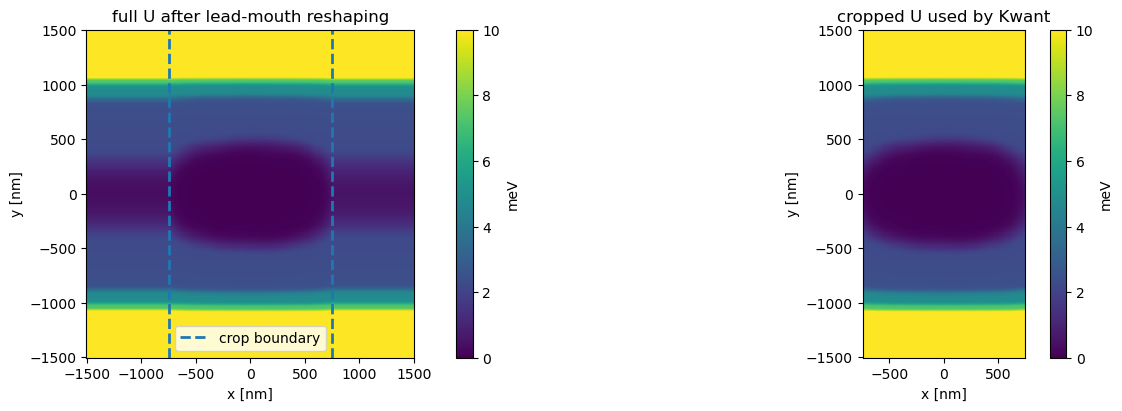

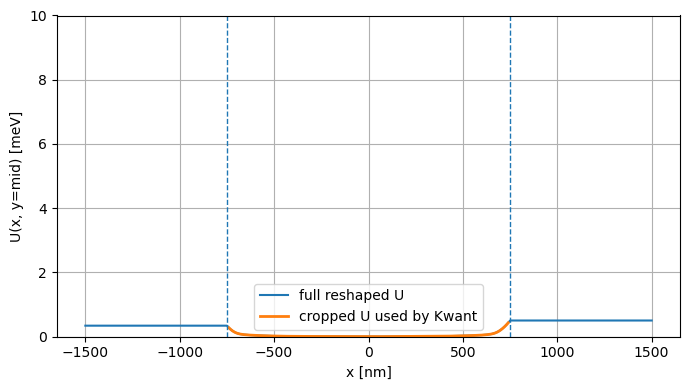

In [4]:
# Full frame after the ORIGINAL lead-mouth reshaping.
prep2_full = _prepare_frame_full(seq, FRAME_INDEX, cfg2)

xmin_full = float(prep2_full.x_nm.min())
xmax_full = float(prep2_full.x_nm.max())
x_left_crop = xmin_full + source_drain_depth_nm
x_right_crop = xmax_full - source_drain_depth_nm

# Cropped frame actually used for transport.
prep2 = prepare_frame(seq, FRAME_INDEX, cfg2)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

im0 = axs[0].pcolormesh(
    prep2_full.x_nm,
    prep2_full.y_nm,
    prep2_full.U_for_transport_meV,
    shading="auto",
    vmin=0,
    vmax=10,
)
axs[0].axvline(x_left_crop, ls="--", lw=2, label="crop boundary")
axs[0].axvline(x_right_crop, ls="--", lw=2)
axs[0].set_aspect("equal")
axs[0].set_xlabel("x [nm]")
axs[0].set_ylabel("y [nm]")
axs[0].set_title("full U after lead-mouth reshaping")
axs[0].legend()
fig.colorbar(im0, ax=axs[0], label="meV")

im1 = axs[1].pcolormesh(
    prep2.x_nm,
    prep2.y_nm,
    prep2.U_for_transport_meV,
    shading="auto",
    vmin=0,
    vmax=10,
)
axs[1].set_aspect("equal")
axs[1].set_xlabel("x [nm]")
axs[1].set_ylabel("y [nm]")
axs[1].set_title("cropped U used by Kwant")
fig.colorbar(im1, ax=axs[1], label="meV")

plt.show()


# Mid-line comparison: the cropped curve is precisely the surviving interior
# of the already-reshaped full transport potential.
plt.figure(figsize=(7, 4))

y_mid_full = len(prep2_full.y_nm) // 2
y_mid_crop = len(prep2.y_nm) // 2

plt.plot(
    prep2_full.x_nm,
    prep2_full.U_for_transport_meV[y_mid_full],
    label="full reshaped U",
)
plt.plot(
    prep2.x_nm,
    prep2.U_for_transport_meV[y_mid_crop],
    lw=2,
    label="cropped U used by Kwant",
)
plt.axvline(x_left_crop, ls="--", lw=1)
plt.axvline(x_right_crop, ls="--", lw=1)

plt.ylim(0, 10)
plt.xlabel("x [nm]")
plt.ylabel("U(x, y=mid) [meV]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 4. Build and inspect one reduced two-terminal Kwant system

The builder receives only the cropped `PreparedFrame`, so the finite scattering region contains no sites belonging to the discarded source/drain reshaping sections. The two full-width leads attach to the new left/right boundaries.


number of leads: 2


/opt/anaconda3/envs/kwant_env/lib/python3.10/site-packages/kwant/_plotter.py:77: RuntimeWarning: plotly is not available, if other engines are unavailable, only iterator-providing functions will work
  warnings.warn("plotly is not available, if other engines are unavailable,"


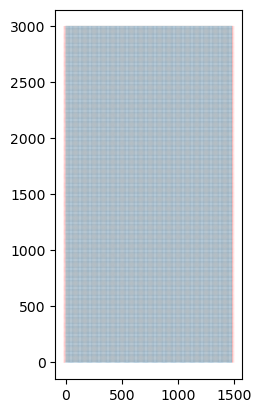

In [5]:
import kwant

builder2 = build_kwant_builder(prep2, cfg2)
fsyst2, phase_params2 = finalize_with_magnetic_field(
    builder2,
    prep2.B_T,
    len(cfg2.lead_specs),
    cfg2.lead_B_mode,
)

print("number of leads:", len(fsyst2.leads))
kwant.plot(fsyst2);

## 5. Run one two-terminal frame

By default the module reads the Hartree chemical potential from metadata. If your metadata uses a different name, adjust `key_candidates`.

In [6]:
selector = hartree_energy_selector(
    key_candidates=["params.mu", "mu", "chemical_potential", "chemical_potential_meV", "fermi_energy", "fermi_energy_meV"],
    unit="meV",
)

prep2, smat2, T2 = run_one_frame(
    seq,
    index=FRAME_INDEX,
    cfg=cfg2,
    energy_selector=selector,
)

np.set_printoptions(precision=4, suppress=True)
print("B =", prep2.B_T, "T")
print("energy =", selector(seq.frame(FRAME_INDEX)), "meV")
print("T[i, j] = transmission from lead j into lead i")
print(T2)

G_2terminal = two_terminal_conductance_e2h(T2, source=0, drain=1)
R_2terminal = two_terminal_resistance_h_e2(T2, source=0, drain=1)

print("G_2terminal [e^2/h] =", G_2terminal)
print("R_2terminal [h/e^2] =", R_2terminal)

B = 1.393939393939394 T
energy = 10.944179726752907 meV
T[i, j] = transmission from lead j into lead i
[[0. 5.]
 [5. 0.]]
G_2terminal [e^2/h] = 4.999977675669853
R_2terminal [h/e^2] = 0.20000089297719292


## 6. Run a B sweep

Set `B_STRIDE = 1` for the full sweep.

In [7]:
B_STRIDE = 1
indices = list(range(0, len(seq.B_values_T), B_STRIDE))

N_JOBS = max(1, multiprocessing.cpu_count() - 1)

def run_one_index(i):
    prep_i, smat_i, T_i = run_one_frame(
        seq,
        index=i,
        cfg=cfg2,
        energy_selector=selector,
    )

    G_i = two_terminal_conductance_e2h(T_i, source=0, drain=1)
    R_i = two_terminal_resistance_h_e2(T_i, source=0, drain=1)

    return {
        "index": i,
        "B_T": prep_i.B_T,
        "energy_meV": selector(seq.frame(i)),
        "T": T_i,
        "G_2terminal_e2h": G_i,
        "R_2terminal_h_e2": R_i,
        # Backward-compatible alias with the old six-terminal notebook.
        # For a two-lead device this is exactly the two-terminal conductance.
        "G10_e2h": T_i[1, 0],
    }


results2 = Parallel(
    n_jobs=N_JOBS,
    backend="loky",      # process-based parallelism
    verbose=10,
)(
    delayed(run_one_index)(i)
    for i in indices
)

results2 = sorted(results2, key=lambda r: r["index"])

B = np.array([r["B_T"] for r in results2])
mu = np.array([r["energy_meV"] for r in results2])
G_2terminal = np.array([r["G_2terminal_e2h"] for r in results2])
R_2terminal = np.array([r["R_2terminal_h_e2"] for r in results2])
G10 = np.array([r["G10_e2h"] for r in results2])

print("done", len(results2), "frames")

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:  1.5min
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:  3.1min
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:  4.6min
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:  6.1min
[Parallel(n_jobs=7)]: Done  36 tasks      | elapsed:  9.2min
[Parallel(n_jobs=7)]: Done  47 tasks      | elapsed: 10.8min
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed: 13.9min
[Parallel(n_jobs=7)]: Done  71 tasks      | elapsed: 16.8min
[Parallel(n_jobs=7)]: Done  84 tasks      | elapsed: 18.6min
[Parallel(n_jobs=7)]: Done  99 out of 101 | elapsed: 22.7min remaining:   27.5s
[Parallel(n_jobs=7)]: Done 101 out of 101 | elapsed: 22.9min finished


done 101 frames


## 7. Plot two-terminal observables

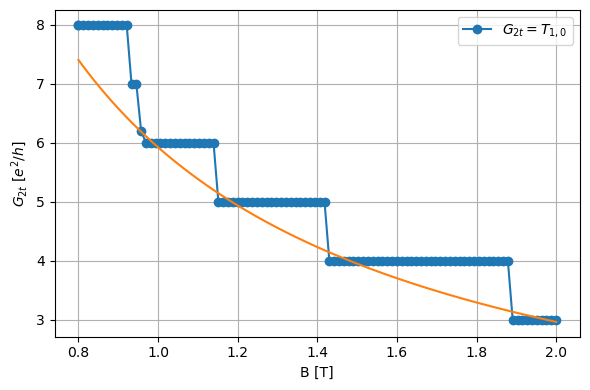

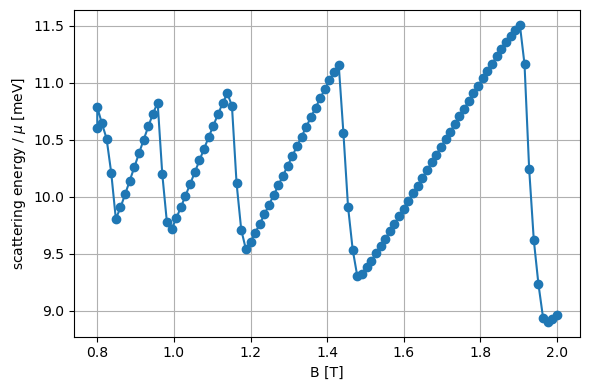

In [8]:
from scipy.ndimage import gaussian_filter

Gsmooth = gaussian_filter( G_2terminal, sigma=.1 )

plt.figure(figsize=(6, 4))
plt.plot(B, Gsmooth, marker="o", label=r"$G_{2t}=T_{1,0}$")
plt.plot(B, 1.45*1e-3* 2*np.pi*25.5**2/B)

plt.xlabel("B [T]")
plt.ylabel(r"$G_{2t}$ [$e^2/h$]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#plt.figure(figsize=(6, 4))
#plt.plot(B, R_2terminal, marker="o", label=r"$1/G_{2t}$")
#plt.xlabel("B [T]")
#plt.ylabel(r"$R_{2t}$ [$h/e^2$]")
#plt.yscale("log")
#plt.grid(True)
#plt.legend()
#plt.tight_layout()
#plt.show()

plt.figure(figsize=(6, 4))
plt.plot(B, mu, marker="o")
plt.xlabel("B [T]")
plt.ylabel(r"scattering energy / $\mu$ [meV]")
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Save numerical results

In [10]:
outfile = "two_terminal_transport_results.npz"
np.savez(
    outfile,
    B=B,
    mu=mu,
    G_2terminal=G_2terminal,
    R_2terminal=R_2terminal,
    G10=G10,
    T_stack=np.stack([r["T"] for r in results2], axis=0),
    indices=np.array([r["index"] for r in results2]),
)
print("saved", outfile)

saved two_terminal_transport_results.npz
